# XOPT - INTERPRETABLE METAHEURISTICS FOR COMBINATORIAL OPTIMIZATION

## SELF-ORGANIZING MAPS

This notebook builds a full, reproducible pipeline to analyze structural patterns in binary p-median solutions using a SOM.

### CONTEXT AND SIMULATION ASSUMPTIONS

We assume:

- `X` is a binary matrix of shape `(m, n)` where each row is a candidate solution and each column is a facility;
- `X[i, j] = 1` means solution `i` opens facility `j`, `0` otherwise;
- `costs` is a vector of objective values for each solution in `X` (lower is better);
- We load a p-median instance and generate long-term memory solutions via `pymedian.solve_pmedian`.

Methodological assumptions:

- SOM is used as a topology-preserving representation to reveal structural neighborhoods of solutions;
- Neuron clustering reveals high-level strategy families, facility frequencies explain each family.

In [1]:
import sys
import random
import warnings

import numpy   as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from minisom import MiniSom

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, \
                            pairwise_distances

In [2]:
warnings.filterwarnings("ignore")

In [3]:
GLOBAL_SEED = 42

np.random.seed(GLOBAL_SEED)
random   .seed(GLOBAL_SEED)

### LOAD SOLUTIONS

In [4]:
def find_project_root(start = None):
    start = (start or Path.cwd()).resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "instances").exists() and \
           (candidate / "pymedian" ).exists():
            return candidate

    raise FileNotFoundError(
        "Could not find project root containing 'instances' and 'pymedian'."
    )


def load_solutions_from_pymedian(
    instance_name : str = "pmed11.txt",
    restarts      : int = 8 ,
    max_iter      : int = 25,
    factor        : int = 2 ,
):
    project_root = find_project_root()

    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))

    import pymedian

    instance_path = (
        project_root / "instances" / instance_name
    )

    if not instance_path.exists():
        raise FileNotFoundError("Instance not found!")

    summary, details = pymedian.solve_pmedian(
        str(instance_path),
        restarts=restarts ,
        max_iter=max_iter ,
        factor  =factor   ,
    )

    memory = details.get("long_term_memory", [])
    if not memory:
        raise ValueError("No long-term memory solutions were returned.")

    X     = np.vstack ([np.asarray(sol["facilities"], dtype=int) for sol in memory])
    costs = np.asarray([float     (sol["cost"      ]           ) for sol in memory], dtype=float)

    order = np.argsort(costs)

    X     = X    [order]
    costs = costs[order]

    return summary, details, X, costs

In [5]:
INSTANCE_NAME = "pmed11.txt"

RESTARTS = 8
MAX_ITER = 25
FACTOR   = 2


summary, details, X, costs = load_solutions_from_pymedian(
    instance_name=INSTANCE_NAME,
    restarts     =RESTARTS,
    max_iter     =MAX_ITER,
    factor       =FACTOR  ,
)


print(f"Instance {summary['instance'][:-4]} ({summary['p']}-{summary['n']})")

print()
print(f"  K-Medoids ({summary['kmedoids_cost']}): {summary['medoids'          ][:10]}")
print(f"  TSPMED    ({summary['tspmed_cost'  ]}): {summary['tspmed_facilities'][:10]}")

print()
print(f"Obs.: Distinct solutions recorded in long term memory is {summary['long_term_mem']}!")

Instance /home/rei-luisinho/xopt/instances/pmed11 (5-300)

  K-Medoids (7696.0): [201, 167, 98, 24, 31]
  TSPMED    (7696.0): [201, 167, 98, 24, 31]

Obs.: Distinct solutions recorded in long term memory is 839!


### PREPROCESSING AND BINARY DISTANCES

We optionally filter to near-optimal solutions, then compute binary dissimilarities. Why Euclidean distance is not ideal here:

- Euclidean distance treats vectors as continuous points and penalizes magnitude geometry;
- Our vectors are binary *set selections*, where overlap and mismatch structure matter more;
- Jaccard distance focuses on set overlap (`1`s), while Hamming captures bitwise disagreement.

In [6]:
def filter_near_optimal_solutions(
    X_in      : np.ndarray,
    costs_in  : np.ndarray,
    tolerance : float = 0.03
):
    best      = float (np.min(costs_in))
    threshold = best * (1.0 + tolerance)

    mask = costs_in <= threshold

    if np.sum(mask) < 3:
        raise ValueError(
            "Near-optimal filter selected fewer than 3 solutions, increase tolerance."
        )

    return X_in[mask], costs_in[mask], mask


def hamming_distance_matrix(X_in):
    return pairwise_distances(X_in, metric="hamming")

def jaccard_distance_matrix(X_in):
    return pairwise_distances(X_in, metric="jaccard")

In [7]:
NEAR_OPTIMAL_TOLERANCE = 0.1


X_model, costs_model, model_mask = filter_near_optimal_solutions(
    X    ,
    costs,
    tolerance=NEAR_OPTIMAL_TOLERANCE,
)


print(f"Modeling solutions is {len(X_model)}/{len(X)}.")

Modeling solutions is 839/839.


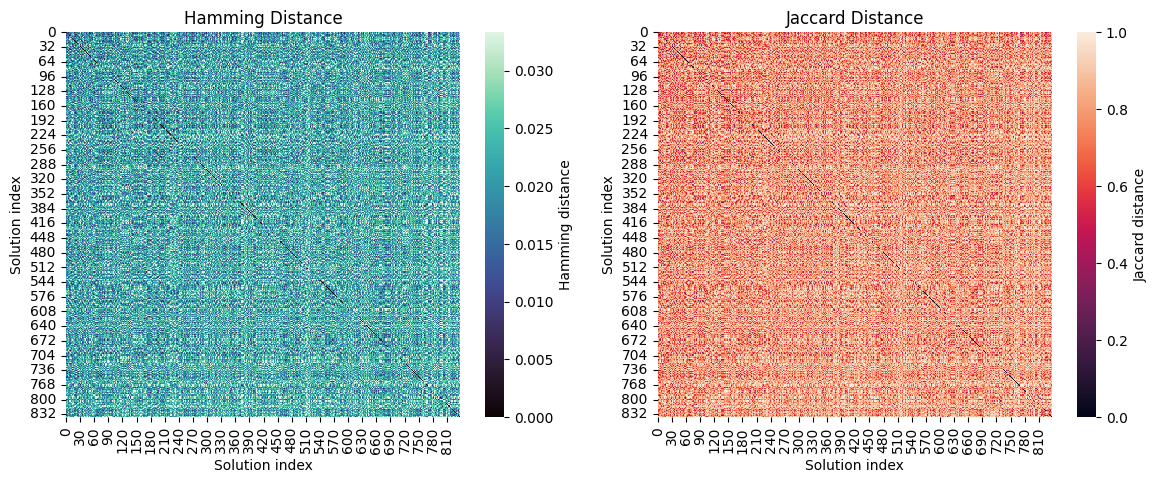

In [8]:
D_hamming = hamming_distance_matrix(X_model)
D_jaccard = jaccard_distance_matrix(X_model)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    D_hamming, ax=axes[0], cmap="mako", cbar_kws={"label": "Hamming distance"}
)

axes[0].set_title ("Hamming Distance")
axes[0].set_xlabel("Solution index")
axes[0].set_ylabel("Solution index")

sns.heatmap(
    D_jaccard, ax=axes[1], cmap="rocket", cbar_kws={"label": "Jaccard distance"}
)

axes[1].set_title ("Jaccard Distance")
axes[1].set_xlabel("Solution index")
axes[1].set_ylabel("Solution index")

plt.show()

### TRAIN A SELF-ORGANIZING MAP

In [9]:
def suggest_grid(n_samples: int):
    side = int(np.sqrt(5 * np.sqrt(n_samples)))

    return side, side


def train_som(
    X_in     ,
    grid_size,
    sigma          = 1.2 ,
    learning_rate  = 0.3 ,
    num_iterations = None,
    seed = 42,
):
    X_float = X_in.astype(float)

    if grid_size      is None:
        grid_size      = suggest_grid(   len(X_float))
    if num_iterations is None:
        num_iterations = max(2000, 500 * len(X_float))

    gx, gy = grid_size

    som_model = MiniSom(
        gx              ,
        gy              ,
        X_float.shape[1],
        sigma         =sigma        ,
        learning_rate =learning_rate,
        random_seed   =seed         ,
        activation_distance='cosine',
    )

    som_model.random_weights_init(X_float)
    som_model.train_random       (X_float, num_iterations, verbose=False)

    qe = float(
        np.mean(
            [
                np.linalg.norm(
                    x - som_model.get_weights()[som_model.winner(x)]
                )
                for x in X_float
            ]
        )
    )

    return som_model, qe

In [10]:
GRID_SIZE         = (7, 7)
SOM_SIGMA         = 1.0
SOM_LEARNING_RATE = 0.5


som, qe = train_som(
    X_model,
    grid_size    =GRID_SIZE,
    sigma        =SOM_SIGMA,
    learning_rate=SOM_LEARNING_RATE,
    seed         =GLOBAL_SEED      ,
)

In [11]:
umatrix = som.distance_map()
weights = som.get_weights ()

grid_shape = umatrix.shape

bmu = np.array(
    [
        som.winner(x.astype(float))
        for x in X_model
    ],
    dtype=int
)


print(f"SOM grid shape is {grid_shape[0]}x{grid_shape[1]}")
print(f"Quantization error is {qe:.2f}")

SOM grid shape is 7x7
Quantization error is 1.12


### VISUALIZATIONS

We visualize:

- U-Matrix (neuron separation intensity);
- Number of solutions mapped to each neuron (hit map);
- Average cost per neuron to identify low-cost concentration regions.

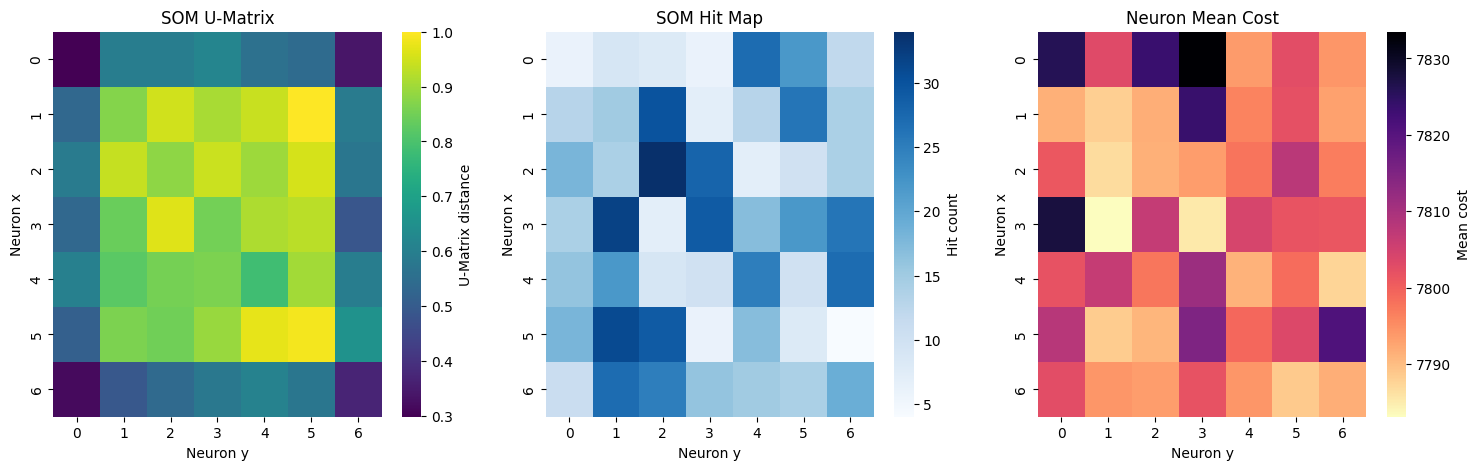

In [12]:
def neuron_cost_statistics(bmu_in, costs_in, grid_shape_in):
    hits = np.zeros(grid_shape_in, dtype=int  )
    sums = np.zeros(grid_shape_in, dtype=float)

    for (r, c), cost in zip(bmu_in, costs_in):
        hits[r, c] += 1
        sums[r, c] += float(cost)

    means = np.divide(
        sums,
        hits,
        where=hits > 0,
        out  =np.full(
            grid_shape_in, np.nan, dtype=float
        ),
    )

    return hits, means


hits, neuron_mean_cost = neuron_cost_statistics(
    bmu, costs_model, grid_shape
)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(
    umatrix, cmap="viridis", ax=axes[0], cbar_kws={"label": "U-Matrix distance"}
)

axes[0].set_title ("SOM U-Matrix")
axes[0].set_xlabel("Neuron y")
axes[0].set_ylabel("Neuron x")

sns.heatmap(
    hits, cmap="Blues", ax=axes[1], cbar_kws={"label": "Hit count"}, annot=False
)

axes[1].set_title ("SOM Hit Map")
axes[1].set_xlabel("Neuron y")
axes[1].set_ylabel("Neuron x")

sns.heatmap(
    neuron_mean_cost, cmap="magma_r", ax=axes[2], cbar_kws={"label": "Mean cost"}
)

axes[2].set_title ("Neuron Mean Cost")
axes[2].set_xlabel("Neuron y")
axes[2].set_ylabel("Neuron x")

plt.show()

### CLUSTER SOM NEURONS

We cluster neuron weight vectors with K-Means. The selected `k` maximizes silhouette score in a candidate range and each solution inherits the cluster of its BMU neuron.

In [13]:
def select_k_by_silhouette(features, k_min=2, k_max=8, seed=42):
    scores = {}

    for k in range(k_min, k_max + 1):
        kmeans = KMeans(
            n_clusters=k, n_init=20, random_state=seed
        )

        labels = kmeans.fit_predict(features)

        if len(np.unique(labels)) > 1:
            scores[k] = float(silhouette_score(features, labels))
        else:
            scores[k] = -1.0

    best_k = max(scores, key=scores.get)

    return best_k, scores


weight_features = weights.reshape(-1, weights.shape[-1])

best_k, silhouette_scores = select_k_by_silhouette(
    weight_features, k_min=2, k_max=8, seed=GLOBAL_SEED
)

neuron_kmeans = KMeans(
    n_clusters=best_k, n_init=30, random_state=GLOBAL_SEED
)

neuron_cluster_flat = neuron_kmeans      .fit_predict(weight_features)
neuron_clusters     = neuron_cluster_flat.reshape    (grid_shape     )

solution_clusters = neuron_clusters[bmu[:, 0], bmu[:, 1]]


print(f"Chosen number of clusters is {best_k}!")
print()

print("Silhouette scores:")
for k, v in silhouette_scores.items():
    print(f"  k ({k}) = {v:.3f}")

Chosen number of clusters is 3!

Silhouette scores:
  k (2) = 0.141
  k (3) = 0.168
  k (4) = 0.125
  k (5) = 0.134
  k (6) = 0.155
  k (7) = 0.132
  k (8) = 0.118


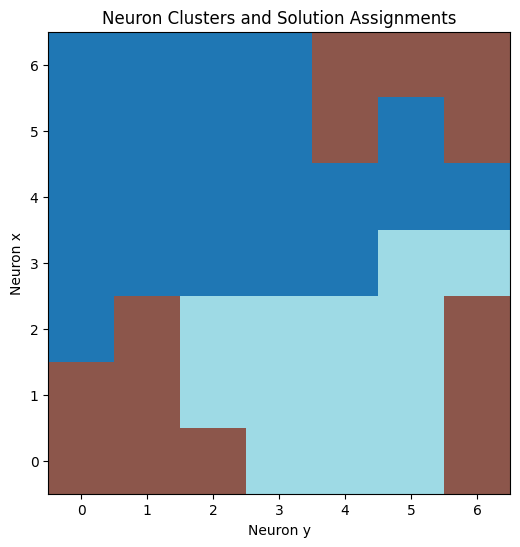

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.imshow(
    neuron_clusters, cmap="tab20", origin="lower"
)

ax.set_title ("Neuron Clusters and Solution Assignments")
ax.set_xlabel("Neuron y")
ax.set_ylabel("Neuron x")

plt.show()

### ANALYSIS OF THE TOPOLOGY OF THE SOLUTIONS

In [15]:
def common_facilities_by_neuron(
    X_in           ,
    bmu_in         ,
    grid_shape_in  ,
    one_based=False,
):
    labels = {}

    for i in range(grid_shape_in[0]):
        for j in range(grid_shape_in[1]):
            mask = (bmu_in[:, 0] == i) & (bmu_in[:, 1] == j)

            if np.any(mask):
                common_idx = np.where(
                    np.all(
                        X_in[mask] == 1, axis=0
                    )
                )[0]

                if one_based:
                    labels[(i, j)] = (common_idx + 1).tolist()
                else:
                    labels[(i, j)] = common_idx.tolist()
            else:
                labels[(i, j)] = []

    return labels


best_cost = float(np.min(costs_model))

neuron_facilities = common_facilities_by_neuron(
    X_model   ,
    bmu       ,
    grid_shape,
)

non_empty = sum(
    1
    for v in neuron_facilities.values()
    if  len(v) > 0
)


print(f"Neurons with at least one common facility is {non_empty}/{len(neuron_facilities)}.")

Neurons with at least one common facility is 48/49.


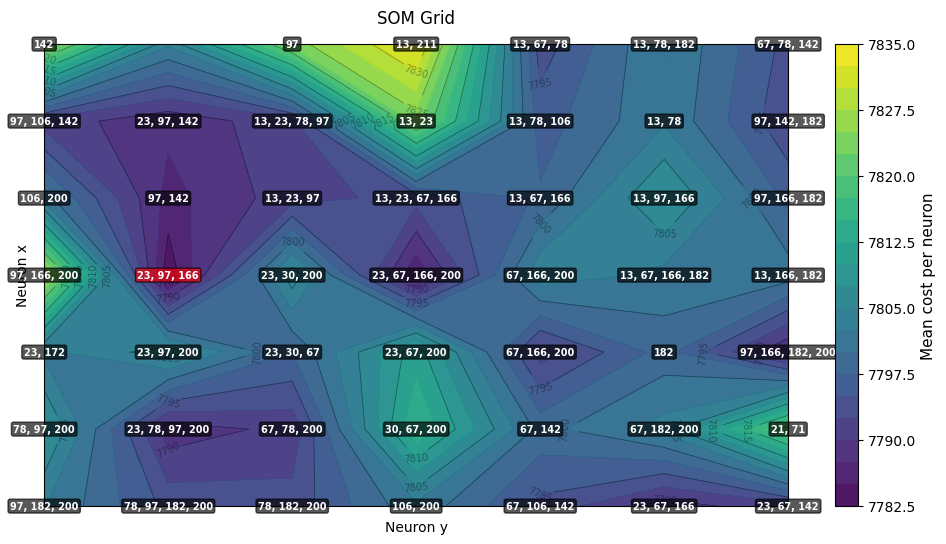

In [16]:
def plot_som_with_contours_and_best_solution(
    neuron_facilities_in,
    bmu_in              ,
    costs_model_in      ,
    grid_shape_in       ,
):
    _, ax = plt.subplots(figsize=(12, 6))

    _, neuron_mean_cost = neuron_cost_statistics(
        bmu_in, costs_model_in, grid_shape_in
    )

    x = np.arange(grid_shape_in[1])
    y = np.arange(grid_shape_in[0])

    X, Y = np.meshgrid(x, y)

    contourf = ax.contourf(
        X,
        Y,
        neuron_mean_cost,
        cmap  ="viridis",
        levels=20  ,
        alpha =0.95,
        zorder=0   ,
    )

    contour = ax.contour(
        X,
        Y,
        neuron_mean_cost,
        colors="black"  ,
        levels    =10   ,
        zorder    =1    ,
        alpha     =0.35 ,
        linewidths=0.6  ,
    )

    ax.clabel(contour, inline=True, fontsize=7)

    cbar = plt.colorbar(contourf, ax=ax)

    cbar.set_label("Mean cost per neuron", fontsize=11)

    best_bmu = bmu_in[
        int(np.nanargmin(costs_model_in))
    ]

    for (i, j), facilities in neuron_facilities_in.items():
        if facilities:
            label_text = ", ".join(map(str, facilities))

            color = "red" if (i, j) == tuple(best_bmu) else "black"

            ax.text(
                j,
                i,
                label_text ,
                ha="center",
                va="center",
                zorder    =3,
                fontsize  =7,
                fontweight="bold" ,
                color     ="white",
                bbox      =dict(
                    boxstyle ="round,pad=0.2",
                    facecolor=color,
                    alpha    =0.65 ,
                ),
            )

    ax.invert_yaxis()
    ax.set_xticks  ([])
    ax.set_yticks  ([])

    ax.set_title ("SOM Grid", pad=15)
    ax.set_xlabel("Neuron y", labelpad=10)
    ax.set_ylabel("Neuron x", labelpad=10)

    plt.show()


plot_som_with_contours_and_best_solution(
    neuron_facilities,
    bmu              ,
    costs_model      ,
    grid_shape       ,
)